In [ ]:
from typing import *
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import seaborn as sns
import numpy as np
import os
import pandas as pd
from glob import glob
from scipy.stats import binomtest

In [ ]:
domain = 'nut_assembly'
operator = 'pick-up-nut-from-peg'
subgoal = 'not_(on-peg_square-nut1_round-peg1)'
rl_algorithm = 'PPO'
agent = 'llm_subgoal'
termination_type = 'on_first_subgoal_success'

def to_filesystem_subgoal_name(subgoal_name: str) -> str:
    """Convert display subgoal tokens to on-disk directory naming."""
    return subgoal_name.replace('grasped_', 'exclusively-occupying-gripper_')

def to_display_subgoal_name(subgoal_name: str) -> str:
    """Convert on-disk directory naming to compact plot labels."""
    return subgoal_name.replace('exclusively-occupying-gripper_', 'grasped_')

In [ ]:
def load_candidate_registry(seed=0):
    """Load the candidate registry from the candidate_registry.npz file in the learning directory
    Returns:
        the candidate registry
    """
    fs_subgoal = to_filesystem_subgoal_name(subgoal)
    path = f'learning/policies/{domain}/llm_subgoal/{operator}/{rl_algorithm}/{termination_type}/seed_{seed}_{rw_type}/{fs_subgoal}/candidate_registry.npz'
    if not os.path.exists(path):
        raise FileNotFoundError(f"Candidate registry file not found at {path}")
    data = np.load(path, allow_pickle=True)
    return data

def _available_candidate_ids(seed=0) -> List[int]:
    fs_subgoal = to_filesystem_subgoal_name(subgoal)
    seed_dir = (
        f'learning/policies/{domain}/llm_subgoal/{operator}/'
        f'{rl_algorithm}/{termination_type}/seed_{seed}_{rw_type}/{fs_subgoal}'
    )
    pattern = os.path.join(seed_dir, 'reward_fn_*_eval', 'eval_logs', 'evaluations.npz')
    eval_paths = glob(pattern)
    candidate_ids = []
    for eval_path in eval_paths:
        candidate_dir = os.path.basename(os.path.dirname(os.path.dirname(eval_path)))
        if candidate_dir.startswith('reward_fn_') and candidate_dir.endswith('_eval'):
            candidate_id_str = candidate_dir[len('reward_fn_'):-len('_eval')]
            try:
                candidate_ids.append(int(candidate_id_str))
            except ValueError:
                continue
    return sorted(set(candidate_ids))

def _available_candidate_ids_for_subgoal(
    domain_name: str,
    operator_name: str,
    subgoal_name: str,
    seed: int,
    rw_type_name: str = 'pos_linear_vel',
) -> List[int]:
    fs_subgoal_name = to_filesystem_subgoal_name(subgoal_name)
    seed_dir = (
        f'learning/policies/{domain_name}/llm_subgoal/{operator_name}/'
        f'{rl_algorithm}/{termination_type}/seed_{seed}_{rw_type_name}/{fs_subgoal_name}'
    )
    pattern = os.path.join(seed_dir, 'reward_fn_*_eval', 'eval_logs', 'evaluations.npz')
    eval_paths = glob(pattern)
    candidate_ids = []
    for eval_path in eval_paths:
        candidate_dir = os.path.basename(os.path.dirname(os.path.dirname(eval_path)))
        if candidate_dir.startswith('reward_fn_') and candidate_dir.endswith('_eval'):
            candidate_id_str = candidate_dir[len('reward_fn_'):-len('_eval')]
            try:
                candidate_ids.append(int(candidate_id_str))
            except ValueError:
                continue
    return sorted(set(candidate_ids))

def _resolve_best_candidate_id(seed=0) -> int:
    available_ids = _available_candidate_ids(seed=seed)
    if not available_ids:
        raise FileNotFoundError(
            f"No candidate eval logs found for seed={seed}, domain={domain}, operator={operator}, subgoal={subgoal}"
        )

    registry = load_candidate_registry(seed=seed)
    if 'best_candidate' in registry and len(registry['best_candidate']) > 0:
        best_candidate = int(registry['best_candidate'][-1])
        if best_candidate in available_ids:
            return best_candidate

    # Fallback when best_candidate history is empty due to filtering / interrupted runs.
    return available_ids[0]

def load_eval(seed=0):
    """Load the best candidate from the candidate registry"""
    if agent == 'llm_subgoal':
        best_candidate = _resolve_best_candidate_id(seed=seed)
        fs_subgoal = to_filesystem_subgoal_name(subgoal)
        path = f'learning/policies/{domain}/llm_subgoal/{operator}/{rl_algorithm}/{termination_type}/seed_{seed}_{rw_type}/{fs_subgoal}/reward_fn_{best_candidate}_eval/eval_logs/evaluations.npz'
    elif agent == 'subgoal':
        path = f'learning/policies/{domain}/{agent}/{operator}/{rl_algorithm}/{termination_type}/seed_{seed}_{rw_type}/{subgoal}_eval/eval_logs/evaluations.npz'
    else:
        path = f'learning/policies/{domain}/{agent}/{operator}/{rl_algorithm}/{termination_type}/seed_{seed}_{rw_type}_eval/eval_logs/evaluations.npz'
    eval = np.load(path, allow_pickle=True)
    return eval

def fix_best_sr(evals):
    # print(evals.files)
    s = evals['subgoal_in_focus_successes']
    # compute success rate
    sr = np.mean(s, axis=1)
    # find rolling max of the subgoal success rate
    bsr = np.zeros_like(sr)
    for i in range(sr.shape[0]):
        if i == 0:
            bsr[i] = sr[i]
        else:
            bsr[i] = max(bsr[i-1], sr[i])
    
    return bsr
def fix_best_gp(evals):
    gp = evals['goal_progress']
    mgp = np.mean(gp, axis=1)
    bgp = np.zeros_like(mgp)
    for i in range(mgp.shape[0]):
        if i == 0:
            bgp[i] = mgp[i]
        else:
            bgp[i] = max(mgp[i-1], bgp[i])
    return bgp
    
def best_sr_and_best_progress(seed=0):
    """find the best subgoal success rate and best goal progress for the best candidate for a given seed"""
    eval = load_eval(seed=seed)
    bsr = eval['best_subgoal_success_rate_so_far'][-1]
    fixed_bsr = fix_best_sr(eval)[-1]

    # best sr is the maximum of the fixed bsr and the bsr
    best_sr = max(bsr, fixed_bsr)
    bp = eval['best_goal_progress_so_far'][-1]
    fixed_bp = fix_best_gp(eval)[-1]
    # best progress is the maximum of the fixed bp and the bp
    best_progress = max(bp, fixed_bp)
    return best_sr, best_progress

def get_all_seeds():
    """Get all seeds from the candidate registry files"""
    srs = []
    progresses = []
    print(f"for {domain} domain, {operator} operator, {subgoal} subgoal, {rl_algorithm} algorithm, {termination_type} termination type, {rw_type} reward shaping function")
    for seed in range(10):
        try:
            best_sr, best_progress = best_sr_and_best_progress(seed=seed)
        except (FileNotFoundError, IndexError, KeyError, ValueError) as e:
            print(f"Skipping seed {seed}: {e}")
            continue
        srs.append(best_sr)
        progresses.append(best_progress)

    return srs, progresses

def best_sr_and_best_progress_across_seeds():
    """compute the average best subgoal success rate and best goal progress across seeds for the best candidate"""
    srs, progresses = get_all_seeds()

    if len(srs) == 0:
        print("No valid seed evaluations found. Returning NaN metrics.")
        return np.nan, np.nan, np.nan, np.nan, srs, progresses

    avg_sr = np.mean(srs)
    avg_progress = np.mean(progresses)
    # calculate the standard deviation of the best subgoal success rate and best goal progress
    if len(srs) > 1:
        std_sr = np.std(srs, ddof=1)/5  # using ddof=1 for sample standard deviation
        std_progress = np.std(progresses, ddof=1)/5
    else:
        std_sr = np.nan
        std_progress = np.nan
    print(f"Average best subgoal success rate across seeds: {avg_sr}")
    print(f"Average best goal progress across seeds: {avg_progress}")
    print(f"Standard deviation of best subgoal success rate across seeds: {std_sr}")
    print(f"Standard deviation of best goal progress across seeds: {std_progress}")
    return avg_sr, avg_progress, std_sr, std_progress, srs, progresses

def binomial_sign_test(expected_larger, expected_smaller):
    """
    Performs a one-sided binomial sign test to check whether llm_subgoal > subgoal.

    Parameters:
        llm_subgoal (array-like): Array of values from the llm_subgoal agent (length 5).
        subgoal (array-like): Array of values from the subgoal agent (length 5).

    Returns:
        p_value (float): One-sided p-value from the binomial sign test.
        num_wins (int): Number of times llm_subgoal > subgoal.
    """
    expected_larger = np.array(expected_larger)
    expected_smaller = np.array(expected_smaller)
    
    # Get number of wins where llm_subgoal > subgoal
    wins = np.sum(expected_smaller < expected_larger)

    # Exclude ties (llm_subgoal == subgoal)
    n = np.sum(expected_larger != expected_smaller)

    if n == 0:
        return 1.0, 0  # No information to support difference

    # Perform one-sided binomial test
    p_value = binomtest(wins, n=n, p=0.5, alternative='greater').pvalue
    return p_value, wins

def compute_p_value(name_one:str, condition_one: np.array, name_two:str, condition_two: np.array) -> float:
    """Compute the one-sided p-value for two paired conditions."""
    if len(condition_one) != len(condition_two):
        raise ValueError("The two conditions must have the same length")
    p_value, _ = binomial_sign_test(condition_two, condition_one)
    return p_value

def get_preferred_operator_order(srs: Dict[str, Dict[str, float]]) -> List[str]:
    preferred_operator_order = [
        'pick-up-lid-from-pot',
        'pick-up-nut-from-peg',
        'pick-up-from-open-box',
        'open-drawer',
        'pick-up-from-open-drawer',
    ]
    operators = [op for op in preferred_operator_order if op in srs]
    operators.extend(op for op in srs.keys() if op not in operators)
    return operators

def calculate_pairwise_p_value_table(
    sr_lists: Dict[str, Dict[str, List[float]]],
    pr_lists: Dict[str, Dict[str, List[float]]],
    operators: List[str],
)-> Tuple[pd.DataFrame, pd.DataFrame]:
    comparisons = [
        ('base', 'subgoal'),
        ('subgoal', 'llm_subgoal'),
        ('base', 'llm_subgoal'),
    ]
    comparison_labels = [f'{left_agent} vs {right_agent}' for left_agent, right_agent in comparisons]
    sr_data = {}
    pr_data = {}
    for operator in operators:
        sr_row = {}
        pr_row = {}
        for left_agent, right_agent in comparisons:
            comparison_label = f'{left_agent} vs {right_agent}'
            sr_row[comparison_label] = float(compute_p_value(
                left_agent,
                sr_lists[operator][left_agent],
                right_agent,
                sr_lists[operator][right_agent],
            ))
            pr_row[comparison_label] = float(compute_p_value(
                left_agent,
                pr_lists[operator][left_agent],
                right_agent,
                pr_lists[operator][right_agent],
            ))
        sr_data[operator] = sr_row
        pr_data[operator] = pr_row
    sr_df = pd.DataFrame.from_dict(sr_data, orient='index')[comparison_labels]
    pr_df = pd.DataFrame.from_dict(pr_data, orient='index')[comparison_labels]
    sr_df.index.name = 'operator'
    pr_df.index.name = 'operator'
    return sr_df, pr_df

def load_ranked_candidate_eval_for_operator(
    domain_name: str,
    operator_name: str,
    subgoal_name: str,
    seed: int,
    rank: int = 1,
    rw_type_name: str = 'pos_linear_vel',
):
    fs_subgoal_name = to_filesystem_subgoal_name(subgoal_name)
    available_ids = _available_candidate_ids_for_subgoal(
        domain_name,
        operator_name,
        subgoal_name,
        seed,
        rw_type_name=rw_type_name,
    )
    if not available_ids:
        raise FileNotFoundError(
            f"No candidate eval logs found for {domain_name}/{operator_name}/{subgoal_name}, seed={seed}"
        )

    candidate_registry_path = (
        f'learning/policies/{domain_name}/llm_subgoal/{operator_name}/'
        f'{rl_algorithm}/{termination_type}/seed_{seed}_{rw_type_name}/'
        f'{fs_subgoal_name}/candidate_registry.npz'
    )
    registry = None
    if os.path.exists(candidate_registry_path):
        registry = np.load(candidate_registry_path, allow_pickle=True)

    eliminated = registry.get('eliminated', []) if registry is not None else []
    best_candidate_list = registry.get('best_candidate', []) if registry is not None else []

    if rank == 1:
        if len(best_candidate_list) > 0 and int(best_candidate_list[-1]) in available_ids:
            candidate_id = int(best_candidate_list[-1])
        else:
            # Fallback when best_candidate history is empty/inconsistent.
            candidate_id = available_ids[-1]
    elif rank == 2:
        if len(eliminated) > 0 and int(eliminated[-1]) in available_ids:
            candidate_id = int(eliminated[-1])
        elif len(available_ids) >= 2:
            candidate_id = available_ids[-2]
        else:
            raise ValueError(f"No second-best candidate available for {candidate_registry_path}")
    elif rank == 3:
        if len(eliminated) > 0 and int(eliminated[0]) in available_ids and len(available_ids) >= 3:
            candidate_id = int(eliminated[0])
        elif len(available_ids) >= 3:
            candidate_id = available_ids[0]
        else:
            raise ValueError(f"No worst candidate available for {candidate_registry_path}")
    else:
        raise ValueError(f"Unsupported candidate rank: {rank}")
    eval_path = (
        f'learning/policies/{domain_name}/llm_subgoal/{operator_name}/'
        f'{rl_algorithm}/{termination_type}/seed_{seed}_{rw_type_name}/'
        f'{fs_subgoal_name}/reward_fn_{candidate_id}_eval/eval_logs/evaluations.npz'
    )
    return np.load(eval_path, allow_pickle=True)

def get_eval_curve_configs() -> List[Dict[str, str]]:
    domain_order = ['kitchen', 'nut_assembly', 'coffee_box', 'coffee_drawer']
    configs = []
    for domain_name in domain_order:
        operator_base = os.path.join('learning', 'policies', domain_name, 'llm_subgoal')
        if not os.path.isdir(operator_base):
            continue
        operators = sorted(
            op for op in os.listdir(operator_base)
            if os.path.isdir(os.path.join(operator_base, op)) and 'no-filtering' not in op
        )
        operators = [op for op in get_preferred_operator_order({op: {} for op in operators}) if op in operators] + [
            op for op in operators if op not in get_preferred_operator_order({op: {} for op in operators})
        ]
        for operator_name in operators:
            seed_pattern = os.path.join(
                operator_base,
                operator_name,
                rl_algorithm,
                termination_type,
                'seed_*_pos_linear_vel',
            )
            subgoals = set()
            for seed_dir in sorted(glob(seed_pattern)):
                for name in os.listdir(seed_dir):
                    if os.path.isdir(os.path.join(seed_dir, name)) and 'no-filtering' not in name:
                        subgoals.add(name)
            for subgoal_name in order_subgoals(operator_name, list(subgoals)):
                configs.append({
                    'domain': domain_name,
                    'operator': operator_name,
                    'subgoal': subgoal_name,
                })
    return configs

def format_subgoal_label(subgoal_name: str) -> str:
    return to_display_subgoal_name(subgoal_name)

def wrap_title_text(text: str, width: int = 18) -> str:
    if len(text) <= width:
        return text

    midpoint = len(text) // 2
    split_chars = ["_", "-", " "]
    best_idx = None
    best_dist = None

    for idx, char in enumerate(text):
        if char not in split_chars:
            continue
        dist = abs(idx - midpoint)
        if (best_dist is None) or (dist < best_dist):
            best_idx = idx
            best_dist = dist

    if best_idx is None:
        return text

    return text[: best_idx + 1] + "\n" + text[best_idx + 1 :]

def order_subgoals(operator_name: str, subgoals: List[str]) -> List[str]:
    preferred_orders = {
        'pick-up-lid-from-pot': [
            'exclusively-occupying-gripper_lid1_gripper1',
            'not_(ontop_lid1_pot1)',
            'not_(covered_pot1)',
        ],
    }
    preferred = preferred_orders.get(operator_name, [])
    ordered = [subgoal for subgoal in preferred if subgoal in subgoals]
    ordered.extend(subgoal for subgoal in sorted(subgoals) if subgoal not in ordered)
    return ordered

def plot_candidate_eval_curves(operator_configs, output_path='candidates_eval_curves.pdf'):
    n_plots = len(operator_configs)
    n_rows = 2
    n_cols = int(np.ceil(n_plots / n_rows))
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(3.8 * n_cols, 3.6 * n_rows), sharex=False, sharey=True)
    axs = np.atleast_2d(axs)

    for plot_idx, config in enumerate(operator_configs):
        row, col = divmod(plot_idx, n_cols)
        ax = axs[row, col]
        has_rank_curve = False
        rank_styles = {
            1: dict(sr_color='tab:blue', label='best', linestyle='-', marker='o', markevery=4),
            2: dict(sr_color='tab:green', label='second', linestyle='--', marker='s', markevery=5),
            3: dict(sr_color='tab:purple', label='worst', linestyle=':', marker='^', markevery=6),
        }
        for rank, style in rank_styles.items():
            sr_curves = []
            timestep_curves = []
            for seed in range(10):
                try:
                    evals = load_ranked_candidate_eval_for_operator(
                        config['domain'],
                        config['operator'],
                        config['subgoal'],
                        seed,
                        rank=rank,
                    )
                except (FileNotFoundError, ValueError, IndexError):
                    continue
                timestep_curves.append(evals['timesteps'])
                sr_curves.append(np.maximum(evals['best_subgoal_success_rate_so_far'], fix_best_sr(evals)))

            if len(sr_curves) == 0:
                continue

            all_timesteps = np.array(sorted(set(np.concatenate(timestep_curves))))
            aligned_curves = np.full((len(sr_curves), len(all_timesteps)), np.nan)
            timestep_to_idx = {timestep: idx for idx, timestep in enumerate(all_timesteps)}
            for seed_idx, (seed_timesteps, seed_curve) in enumerate(zip(timestep_curves, sr_curves)):
                for timestep, value in zip(seed_timesteps, seed_curve):
                    aligned_curves[seed_idx, timestep_to_idx[timestep]] = value

            sr_mean = np.nanmean(aligned_curves, axis=0)
            valid_counts = np.sum(~np.isnan(aligned_curves), axis=0)
            sr_std = np.nanstd(aligned_curves, axis=0, ddof=1)
            sr_std[valid_counts <= 1] = 0.0

            ax.plot(
                all_timesteps,
                sr_mean,
                color=style['sr_color'],
                label=style['label'],
                linestyle=style['linestyle'],
                marker=style['marker'],
                markevery=style['markevery'],
                linewidth=2,
                markersize=4,
            )
            ax.fill_between(all_timesteps, sr_mean - sr_std, sr_mean + sr_std, color=style['sr_color'], alpha=0.15)
            has_rank_curve = True

        operator_title = config['operator']
        subgoal_title = wrap_title_text(format_subgoal_label(config['subgoal']), width=18)
        full_title = f"{operator_title}\n{subgoal_title}"
        ax.set_title(full_title, fontsize=17, pad=14)
        ax.set_ylabel('Success Rate', fontsize=16)
        ax.set_xlabel('Timesteps', fontsize=16)
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis='both', labelsize=14)
        ax.locator_params(axis='x', nbins=4)
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((5, 5))
        ax.xaxis.set_major_formatter(formatter)
        if has_rank_curve:
            ax.legend(fontsize=16)

    for plot_idx in range(n_plots, n_rows * n_cols):
        row, col = divmod(plot_idx, n_cols)
        axs[row, col].axis('off')

    fig.tight_layout()
    fig.subplots_adjust(hspace=0.95, wspace=0.2)
    plt.savefig(output_path, format='pdf', bbox_inches='tight')

In [ ]:
domain = 'nut_assembly'
operator = 'pick-up-nut-from-peg'
subgoal = 'not_(on-peg_square-nut1_round-peg1)'

agent = 'base'
rw_type = 'pos_sparse'
srs = {}
prs = {}
srs_stds = {}
prs_stds = {}
sr_lists = {}
pr_lists = {}
sr, pr, std_sr, std_pr, srs_list, prs_list = best_sr_and_best_progress_across_seeds()
srs[operator] = {agent: sr }  # add a small constant to avoid zero success rate
prs[operator] = {agent: pr }  # add a small constant to avoid zero progress
srs_stds[operator] = {agent: std_sr }  # add a small constant to avoid zero success rate
prs_stds[operator] = {agent: std_pr }  # add a small constant to avoid zero progress
sr_lists[operator] = {agent: srs_list}
pr_lists[operator] = {agent: prs_list}

agent = 'subgoal'
rw_type = 'pos_subgoal_sparse'
sr, pr, std_sr, std_pr, srs_list, prs_list = best_sr_and_best_progress_across_seeds()
srs[operator][agent] = sr   # add a small constant to avoid zero success rate
prs[operator][agent] = pr   # add a small constant to avoid zero progress
srs_stds[operator][agent] = std_sr
prs_stds[operator][agent] = std_pr
sr_lists[operator][agent] = srs_list
pr_lists[operator][agent] = prs_list

agent = 'llm_subgoal'
rw_type = 'pos_linear_vel'
sr, pr, std_sr, std_pr, srs_list, prs_list = best_sr_and_best_progress_across_seeds()
srs[operator][agent] = sr
prs[operator][agent] = pr
srs_stds[operator][agent] = std_sr
prs_stds[operator][agent] = std_pr
sr_lists[operator][agent] = srs_list
pr_lists[operator][agent] = prs_list

# compute the p-value between the base and subgoal agent
print(f"Computing p-values for {domain} domain, {operator} operator")
compute_p_value('base', sr_lists[operator]['base'], 'subgoal', sr_lists[operator]['subgoal'])
compute_p_value('base', pr_lists[operator]['base'], 'subgoal', pr_lists[operator]['subgoal'])
# compute the p-value between the subgoal and llm_subgoal agent
compute_p_value('subgoal', sr_lists[operator]['subgoal'], 'llm_subgoal', sr_lists[operator]['llm_subgoal'])
compute_p_value('subgoal', pr_lists[operator]['subgoal'], 'llm_subgoal', pr_lists[operator]['llm_subgoal'])
# compute the p-value between the base and llm_subgoal agent
compute_p_value('base', sr_lists[operator]['base'], 'llm_subgoal', sr_lists[operator]['llm_subgoal'])
compute_p_value('base', pr_lists[operator]['base'], 'llm_subgoal', pr_lists[operator]['llm_subgoal'])

for nut_assembly domain, pick-up-nut-from-peg operator, not_(on-peg_square-nut1_round-peg1) subgoal, PPO algorithm, on_first_subgoal_success termination type, pos_sparse reward shaping function
Average best subgoal success rate across seeds: 0.0
Average best goal progress across seeds: 0.0
Standard deviation of best subgoal success rate across seeds: 0.0
Standard deviation of best goal progress across seeds: 0.0
for nut_assembly domain, pick-up-nut-from-peg operator, not_(on-peg_square-nut1_round-peg1) subgoal, PPO algorithm, on_first_subgoal_success termination type, pos_subgoal_sparse reward shaping function
Average best subgoal success rate across seeds: 0.12999999999999998
Average best goal progress across seeds: 0.195
Standard deviation of best subgoal success rate across seeds: 0.06168017869984201
Standard deviation of best goal progress across seeds: 0.06740425308044985
for nut_assembly domain, pick-up-nut-from-peg operator, not_(on-peg_square-nut1_round-peg1) subgoal, PPO algor

0.0009765625

In [ ]:
domain = 'kitchen'
operator = 'pick-up-lid-from-pot'
subgoal = 'not_(covered_pot1)'

agent = 'base'
rw_type = 'pos_sparse'
sr, pr, std_sr, std_pr, srs_list, prs_list = best_sr_and_best_progress_across_seeds()
srs[operator] = {agent: sr }  # add a small constant to avoid zero success rate
prs[operator] = {agent: pr }  # add a small constant to avoid zero progress
srs_stds[operator] = {agent: std_sr }
prs_stds[operator] = {agent: std_pr }
sr_lists[operator] = {agent: srs_list}
pr_lists[operator] = {agent: prs_list}

agent = 'subgoal'
rw_type = 'pos_subgoal_sparse'
sr, pr, std_sr, std_pr, srs_list, prs_list = best_sr_and_best_progress_across_seeds()
srs[operator][agent] = sr   # add a small constant to avoid zero success rate
prs[operator][agent] = pr   # add a small constant to avoid zero progress
srs_stds[operator][agent] = std_sr
prs_stds[operator][agent] = std_pr
sr_lists[operator][agent] = srs_list
pr_lists[operator][agent] = prs_list

agent = 'llm_subgoal'
rw_type = 'pos_linear_vel'
sr, pr, std_sr, std_pr, srs_list, prs_list = best_sr_and_best_progress_across_seeds()
srs[operator][agent] = sr
prs[operator][agent] = pr
srs_stds[operator][agent] = std_sr
prs_stds[operator][agent] = std_pr
sr_lists[operator][agent] = srs_list
pr_lists[operator][agent] = prs_list

# compute the p-value between the base and subgoal agent
print(f"Computing p-values for {domain} domain, {operator} operator")
compute_p_value('base', sr_lists[operator]['base'], 'subgoal', sr_lists[operator]['subgoal'])
compute_p_value('base', pr_lists[operator]['base'], 'subgoal', pr_lists[operator]['subgoal'])
# compute the p-value between the subgoal and llm_subgoal agent
compute_p_value('subgoal', sr_lists[operator]['subgoal'], 'llm_subgoal', sr_lists[operator]['llm_subgoal'])
compute_p_value('subgoal', pr_lists[operator]['subgoal'], 'llm_subgoal', pr_lists[operator]['llm_subgoal'])
# compute the p-value between the base and llm_subgoal agent
compute_p_value('base', sr_lists[operator]['base'], 'llm_subgoal', sr_lists[operator]['llm_subgoal'])
compute_p_value('base', pr_lists[operator]['base'], 'llm_subgoal', pr_lists[operator]['llm_subgoal'])

for kitchen domain, pick-up-lid-from-pot operator, not_(covered_pot1) subgoal, PPO algorithm, on_first_subgoal_success termination type, pos_sparse reward shaping function
Average best subgoal success rate across seeds: 0.0
Average best goal progress across seeds: 0.0
Standard deviation of best subgoal success rate across seeds: 0.0
Standard deviation of best goal progress across seeds: 0.0
for kitchen domain, pick-up-lid-from-pot operator, not_(covered_pot1) subgoal, PPO algorithm, on_first_subgoal_success termination type, pos_subgoal_sparse reward shaping function
Average best subgoal success rate across seeds: 0.58
Average best goal progress across seeds: 0.5833333333333334
Standard deviation of best subgoal success rate across seeds: 0.10057611821677925
Standard deviation of best goal progress across seeds: 0.1009216784699164
for kitchen domain, pick-up-lid-from-pot operator, not_(covered_pot1) subgoal, PPO algorithm, on_first_subgoal_success termination type, pos_linear_vel rewar

0.0009765625

In [ ]:
domain = 'coffee_drawer'
operator = 'open-drawer'
subgoal = 'open_drawer1'
agent = 'base'
rw_type = 'pos_sparse'
sr, pr, std_sr, std_pr, srs_list, prs_list = best_sr_and_best_progress_across_seeds()
srs[operator] = {agent: sr }  # add a small constant to avoid zero success rate
prs[operator] = {agent: pr }  # add a small constant to avoid zero progress
srs_stds[operator] = {agent: std_sr }
prs_stds[operator] = {agent: std_pr }
sr_lists[operator] = {agent: srs_list}
pr_lists[operator] = {agent: prs_list}

for coffee_drawer domain, open-drawer operator, open_drawer1 subgoal, PPO algorithm, on_first_subgoal_success termination type, pos_sparse reward shaping function
Average best subgoal success rate across seeds: 0.1
Average best goal progress across seeds: 0.1
Standard deviation of best subgoal success rate across seeds: 0.06324555320336758
Standard deviation of best goal progress across seeds: 0.06324555320336758


In [ ]:
agent = 'subgoal'
rw_type = 'pos_subgoal_sparse'
sr, pr, std_sr, std_pr, srs_list, prs_list = best_sr_and_best_progress_across_seeds()
srs[operator][agent] = sr   # add a small constant to avoid zero success rate
prs[operator][agent] = pr   # add a small constant to avoid zero progress
srs_stds[operator][agent] = std_sr
prs_stds[operator][agent] = std_pr
sr_lists[operator][agent] = srs_list
pr_lists[operator][agent] = prs_list

for coffee_drawer domain, open-drawer operator, open_drawer1 subgoal, PPO algorithm, on_first_subgoal_success termination type, pos_subgoal_sparse reward shaping function
Average best subgoal success rate across seeds: 0.0
Average best goal progress across seeds: 0.15
Standard deviation of best subgoal success rate across seeds: 0.0
Standard deviation of best goal progress across seeds: 0.04830458915396479


In [ ]:
agent = 'llm_subgoal'
rw_type = 'pos_linear_vel'
sr, pr, std_sr, std_pr, srs_list, prs_list = best_sr_and_best_progress_across_seeds()
srs[operator][agent] = sr
prs[operator][agent] = pr
srs_stds[operator][agent] = std_sr
prs_stds[operator][agent] = std_pr
sr_lists[operator][agent] = srs_list
pr_lists[operator][agent] = prs_list

# compute the p-value between the base and subgoal agent
print(f"Computing p-values for {domain} domain, {operator} operator")
compute_p_value('base', sr_lists[operator]['base'], 'subgoal', sr_lists[operator]['subgoal'])
compute_p_value('base', pr_lists[operator]['base'], 'subgoal', pr_lists[operator]['subgoal'])
# compute the p-value between the subgoal and llm_subgoal agent
compute_p_value('subgoal', sr_lists[operator]['subgoal'], 'llm_subgoal', sr_lists[operator]['llm_subgoal'])
compute_p_value('subgoal', pr_lists[operator]['subgoal'], 'llm_subgoal', pr_lists[operator]['llm_subgoal'])
# compute the p-value between the base and llm_subgoal agent
compute_p_value('base', sr_lists[operator]['base'], 'llm_subgoal', sr_lists[operator]['llm_subgoal'])
compute_p_value('base', pr_lists[operator]['base'], 'llm_subgoal', pr_lists[operator]['llm_subgoal'])

for coffee_drawer domain, open-drawer operator, open_drawer1 subgoal, PPO algorithm, on_first_subgoal_success termination type, pos_linear_vel reward shaping function
Average best subgoal success rate across seeds: 1.0
Average best goal progress across seeds: 1.0
Standard deviation of best subgoal success rate across seeds: 0.0
Standard deviation of best goal progress across seeds: 0.0
Computing p-values for coffee_drawer domain, open-drawer operator


0.001953125

In [ ]:
domain = 'coffee_box'
operator = 'pick-up-from-open-box'
subgoal = 'not_(in_coffee-pod1_box1)'
agent = 'base'
rw_type = 'pos_sparse'
sr, pr, std_sr, std_pr, srs_list, prs_list = best_sr_and_best_progress_across_seeds()
srs[operator] = {agent: sr }
prs[operator] = {agent: pr }
srs_stds[operator] = {agent: std_sr }
prs_stds[operator] = {agent: std_pr }
sr_lists[operator] = {agent: srs_list}
pr_lists[operator] = {agent: prs_list}

for coffee_box domain, pick-up-from-open-box operator, not_(in_coffee-pod1_box1) subgoal, PPO algorithm, on_first_subgoal_success termination type, pos_sparse reward shaping function
Average best subgoal success rate across seeds: 0.13999999999999999
Average best goal progress across seeds: 0.1375
Standard deviation of best subgoal success rate across seeds: 0.06214677966091422
Standard deviation of best goal progress across seeds: 0.06303658549692481


In [ ]:
agent = 'subgoal'
rw_type = 'pos_subgoal_sparse'
sr, pr, std_sr, std_pr, srs_list, prs_list = best_sr_and_best_progress_across_seeds()
srs[operator][agent] = sr
prs[operator][agent] = pr
srs_stds[operator][agent] = std_sr
prs_stds[operator][agent] = std_pr
sr_lists[operator][agent] = srs_list
pr_lists[operator][agent] = prs_list

for coffee_box domain, pick-up-from-open-box operator, not_(in_coffee-pod1_box1) subgoal, PPO algorithm, on_first_subgoal_success termination type, pos_subgoal_sparse reward shaping function
Average best subgoal success rate across seeds: 0.075
Average best goal progress across seeds: 0.075
Standard deviation of best subgoal success rate across seeds: 0.047434164902525694
Standard deviation of best goal progress across seeds: 0.047434164902525694


In [ ]:
agent = 'llm_subgoal'
rw_type = 'pos_linear_vel'
sr, pr, std_sr, std_pr, srs_list, prs_list = best_sr_and_best_progress_across_seeds()
srs[operator][agent] = sr
prs[operator][agent] = pr
srs_stds[operator][agent] = std_sr
prs_stds[operator][agent] = std_pr
sr_lists[operator][agent] = srs_list
pr_lists[operator][agent] = prs_list

# compute the p-value between the base and subgoal agent
print(f"Computing p-values for {domain} domain, {operator} operator")
compute_p_value('base', sr_lists[operator]['base'], 'subgoal', sr_lists[operator]['subgoal'])
compute_p_value('base', pr_lists[operator]['base'], 'subgoal', pr_lists[operator]['subgoal'])
# compute the p-value between the subgoal and llm_subgoal agent
compute_p_value('subgoal', sr_lists[operator]['subgoal'], 'llm_subgoal', sr_lists[operator]['llm_subgoal'])
compute_p_value('subgoal', pr_lists[operator]['subgoal'], 'llm_subgoal', pr_lists[operator]['llm_subgoal'])
# compute the p-value between the base and llm_subgoal agent
compute_p_value('base', sr_lists[operator]['base'], 'llm_subgoal', sr_lists[operator]['llm_subgoal'])
compute_p_value('base', pr_lists[operator]['base'], 'llm_subgoal', pr_lists[operator]['llm_subgoal'])

for coffee_box domain, pick-up-from-open-box operator, not_(in_coffee-pod1_box1) subgoal, PPO algorithm, on_first_subgoal_success termination type, pos_linear_vel reward shaping function
Average best subgoal success rate across seeds: 1.0
Average best goal progress across seeds: 1.0
Standard deviation of best subgoal success rate across seeds: 0.0
Standard deviation of best goal progress across seeds: 0.0
Computing p-values for coffee_box domain, pick-up-from-open-box operator


0.0009765625

In [ ]:
domain = 'coffee_drawer'
operator = 'pick-up-from-open-drawer'
subgoal = 'not_(in_coffee-pod1_drawer1)'
agent = 'base'
rw_type = 'pos_sparse'
sr, pr, std_sr, std_pr, srs_list, prs_list = best_sr_and_best_progress_across_seeds()
srs[operator] = {agent: sr }  # add a small constant to avoid zero success rate
prs[operator] = {agent: pr }  # add a small constant to avoid zero progress
srs_stds[operator] = {agent: std_sr }
prs_stds[operator] = {agent: std_pr }
sr_lists[operator] = {agent: srs_list}
pr_lists[operator] = {agent: prs_list}

for coffee_drawer domain, pick-up-from-open-drawer operator, not_(in_coffee-pod1_drawer1) subgoal, PPO algorithm, on_first_subgoal_success termination type, pos_sparse reward shaping function
Average best subgoal success rate across seeds: 0.0
Average best goal progress across seeds: 0.0
Standard deviation of best subgoal success rate across seeds: 0.0
Standard deviation of best goal progress across seeds: 0.0


In [ ]:
agent = 'subgoal'
rw_type = 'pos_subgoal_sparse'
sr, pr, std_sr, std_pr, srs_list, prs_list = best_sr_and_best_progress_across_seeds()
srs[operator][agent] = sr   # add a small constant to avoid zero success rate
prs[operator][agent] = pr   # add a small constant to avoid zero progress
srs_stds[operator][agent] = std_sr
prs_stds[operator][agent] = std_pr
sr_lists[operator][agent] = srs_list
pr_lists[operator][agent] = prs_list

for coffee_drawer domain, pick-up-from-open-drawer operator, not_(in_coffee-pod1_drawer1) subgoal, PPO algorithm, on_first_subgoal_success termination type, pos_subgoal_sparse reward shaping function
Average best subgoal success rate across seeds: 0.0
Average best goal progress across seeds: 0.05
Standard deviation of best subgoal success rate across seeds: 0.0
Standard deviation of best goal progress across seeds: 0.03162277660168379


In [ ]:
agent = 'llm_subgoal'
rw_type = 'pos_linear_vel'
sr, pr, std_sr, std_pr, srs_list, prs_list = best_sr_and_best_progress_across_seeds()
srs[operator][agent] = sr
prs[operator][agent] = pr
srs_stds[operator][agent] = std_sr
prs_stds[operator][agent] = std_pr
sr_lists[operator][agent] = srs_list
pr_lists[operator][agent] = prs_list

# compute the p-value between the base and subgoal agent
print(f"Computing p-values for {domain} domain, {operator} operator")
#compute_p_value('base', sr_lists[operator]['base'], 'subgoal', sr_lists[operator]['subgoal'])
#compute_p_value('base', pr_lists[operator]['base'], 'subgoal', pr_lists[operator]['subgoal'])
# compute the p-value between the subgoal and llm_subgoal agent
compute_p_value('subgoal', sr_lists[operator]['subgoal'], 'llm_subgoal', sr_lists[operator]['llm_subgoal'])
compute_p_value('subgoal', pr_lists[operator]['subgoal'], 'llm_subgoal', pr_lists[operator]['llm_subgoal'])
# compute the p-value between the base and llm_subgoal agent
compute_p_value('base', sr_lists[operator]['base'], 'llm_subgoal', sr_lists[operator]['llm_subgoal'])
compute_p_value('base', pr_lists[operator]['base'], 'llm_subgoal', pr_lists[operator]['llm_subgoal'])

for coffee_drawer domain, pick-up-from-open-drawer operator, not_(in_coffee-pod1_drawer1) subgoal, PPO algorithm, on_first_subgoal_success termination type, pos_linear_vel reward shaping function
Average best subgoal success rate across seeds: 0.985
Average best goal progress across seeds: 0.9799999999999999
Standard deviation of best subgoal success rate across seeds: 0.004830458915396484
Standard deviation of best goal progress across seeds: 0.005163977794943228
Computing p-values for coffee_drawer domain, pick-up-from-open-drawer operator


0.0009765625

In [ ]:
# the first row is the srs, the second row is the prs
# the tile of each plot should include the operator's name and whether it's succes rate or progress
def plot_sr_pr_barplots(srs:Dict[str, Dict[str, float]], prs:Dict[str, Dict[str, float]], srs_stds:Dict[str, Dict[str, float]], prs_stds:Dict[str, Dict[str, float]]):
    """Plot barplots of the subgoal success rates and goal progresses for each operator
    Args:
        srs (Dict[str, Dict[str, float]]): the subgoal success rates for each operator
        prs (Dict[str, Dict[str, float]]): the goal progresses for each operator
    """
    # Filter out no-filtering operators
    filtered_srs = {op: data for op, data in srs.items() if 'no-filtering' not in op}
    operators = [op for op in get_preferred_operator_order(filtered_srs) if 'no-filtering' not in op]
    agents = list(filtered_srs[operators[0]].keys())
    display_agent_names = {
        'base': 'LS',
        'subgoal': 'RM',
        'llm_subgoal': 'LG(ours)',
    }
    agent_labels = [display_agent_names.get(agent, agent) for agent in agents]
    num_operators = len(operators)
    num_agents = len(agents)
    sns.set_theme(palette="colorblind")
    fig, axs = plt.subplots(2, num_operators, figsize=(15, 6), sharey='row')
    
    for i, operator in enumerate(operators):
        # plot the subgoal success rates
        sr_values = [filtered_srs[operator][agent] for agent in agents]
        std_means = [srs_stds[operator][agent] for agent in agents]

        # Make each bar a different color
        # label the numbers
        for j, value in enumerate(sr_values):
            axs[0, i].text(j, min(1, value + std_means[j] + 0.01) , f"{value:.2f}", ha='center', va='bottom',)
    
        # Make each bar's label bigger and rotate by 40 degrees
        axs[0, i].set_xticklabels(agent_labels, fontsize=15, rotation=40)
        # plot the standard deviation as error bars
        axs[0, i].errorbar(agent_labels, sr_values, yerr=std_means, fmt='none', c='black', capsize=5, )
        bars = axs[0, i].bar(agent_labels, sr_values, color=sns.color_palette("colorblind", n_colors=num_agents))
        axs[0, i].set_title(f"{operator}", fontsize=15, pad=14)
        axs[0, i].set_ylabel('Success Rate', fontsize=15)


    for i, operator in enumerate(operators):
        # plot the goal progresses
        pr_values = [prs[operator][agent] for agent in agents]
        pr_std_means = [prs_stds[operator][agent] for agent in agents]
        # Make each bar a different color
        # label the numbers
        for j, value in enumerate(pr_values):
            axs[1, i].text(j, min(1, value + pr_std_means[j] + 0.01) , f"{value:.2f}", ha='center', va='bottom',)
        # Make each bar's label bigger and rotate by 40 degrees
        axs[1, i].set_xticklabels(agent_labels, fontsize=12, rotation=40)
        # plot the standard deviation as error bars
        axs[1, i].errorbar(agent_labels, pr_values, yerr=[prs_stds[operator][agent] for agent in agents], fmt='none', c='black', capsize=5, )
        axs[1, i].bar(agent_labels, pr_values, color=sns.color_palette("colorblind", n_colors=num_agents))
        axs[1, i].set_title(f"{operator}", fontsize=15, pad=14)
        axs[1, i].set_ylabel('Progress', fontsize=15)
    plt.tight_layout()
    # save the figure as a pdf
    plt.savefig("sr_pr_barplots.pdf", format='pdf', bbox_inches='tight')
    #plt.show()

<ipython-input-15-b6c434432ede>:36: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0, i].set_xticklabels(agent_labels, fontsize=15, rotation=40)
<ipython-input-15-b6c434432ede>:53: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[1, i].set_xticklabels(agent_labels, fontsize=12, rotation=40)
/home/helen/hybridPlanningLearning/OpLearn/.venv/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Success rate p-values
                          base vs subgoal  subgoal vs llm_subgoal  \
operator                                                            
pick-up-lid-from-pot             0.015625                0.109375   
pick-up-nut-from-peg             0.250000                0.010742   
pick-up-from-open-box            1.000000                0.000977   
open-drawer                      1.000000                0.000977   
pick-up-from-open-drawer         1.000000                0.000977   

                          base vs llm_subgoal  
operator                                       
pick-up-lid-from-pot                 0.000977  
pick-up-nut-from-peg                 0.000977  
pick-up-from-open-box                0.000977  
open-drawer                          0.001953  
pick-up-from-open-drawer             0.000977  

Progress p-values
                          base vs subgoal  subgoal vs llm_subgoal  \
operator                                                            
p

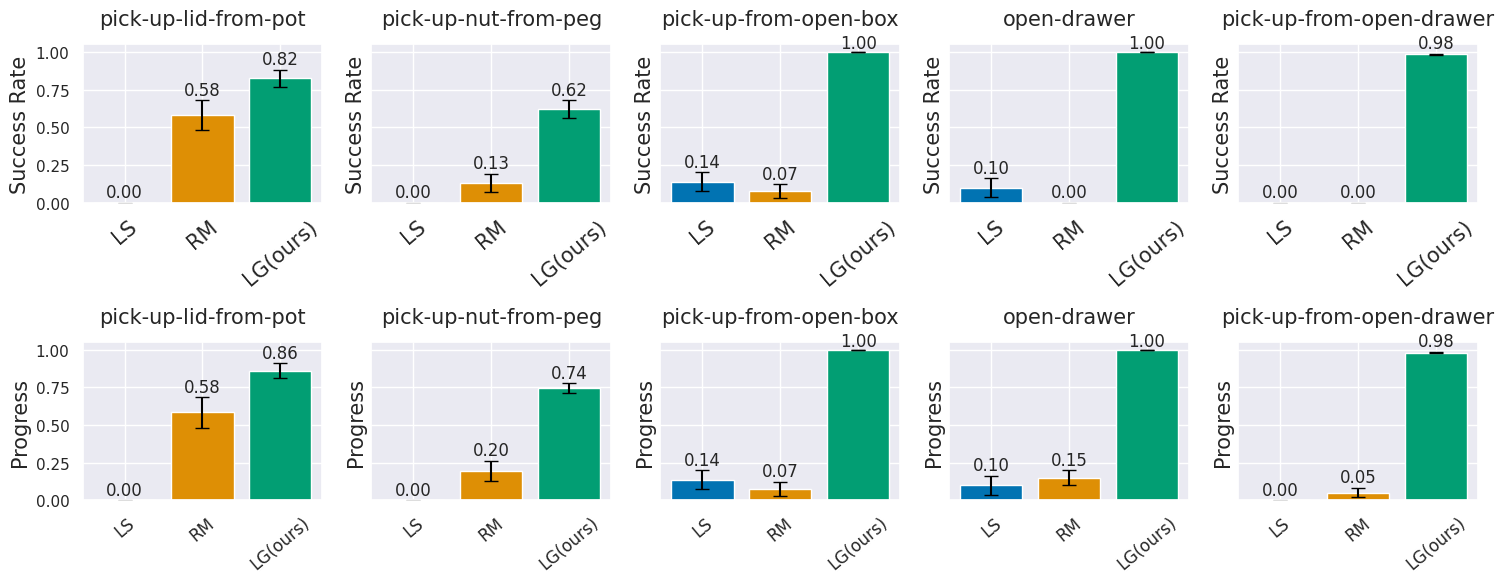

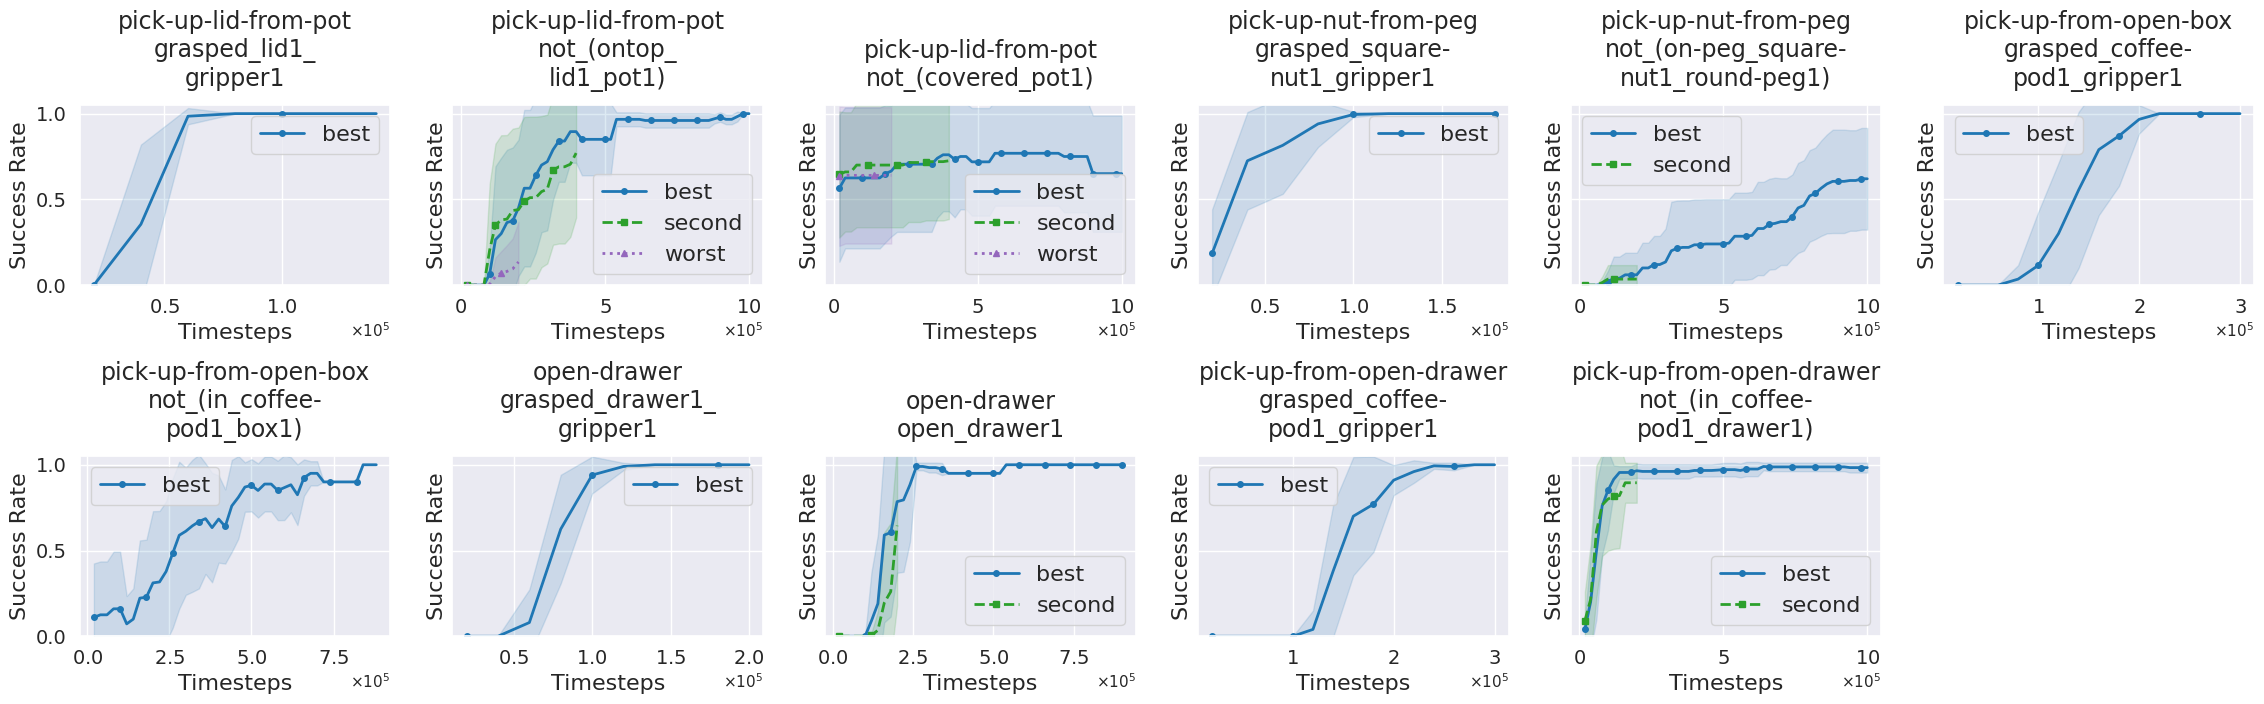

In [ ]:
plot_sr_pr_barplots(srs, prs, srs_stds, prs_stds)
plot_candidate_eval_curves(get_eval_curve_configs())
# Filter out no-filtering operators before calculating p-values
filtered_operators = [op for op in get_preferred_operator_order(srs) if 'no-filtering' not in op]
sr_p_value_df, pr_p_value_df = calculate_pairwise_p_value_table(
    sr_lists,
    pr_lists,
    filtered_operators,
)
print("Success rate p-values")
print(sr_p_value_df)
print("\nProgress p-values")
print(pr_p_value_df)

# Save pairwise p-values to CSV
pairwise_data = []
for op_name in sr_p_value_df.index:
    for comparison_col in sr_p_value_df.columns:
        pairwise_data.append({
            'operator': op_name,
            'metric': 'success_rate',
            'comparison': comparison_col,
            'p_value': sr_p_value_df.loc[op_name, comparison_col]
        })
        pairwise_data.append({
            'operator': op_name,
            'metric': 'progress',
            'comparison': comparison_col,
            'p_value': pr_p_value_df.loc[op_name, comparison_col]
        })

pairwise_p_values_df = pd.DataFrame(pairwise_data)
pairwise_p_values_df.to_csv('pairwise_p_values.csv', index=False)
print("\nPairwise p-values saved to pairwise_p_values.csv")
#

In [ ]:
# parse the log in planning/PDDL/{domain}/HybridPlanner.log to read the time taken for each iteration of the hybrid planner, and compute the average time taken for each iteration

kitchen_hybrid_planner_log = "planning/PDDL/kitchen/HybridPlanner.log"
nut_assembly_hybrid_planner_log = "planning/PDDL/nut_assembly/HybridPlanner.log"
coffee_box_hybrid_planner_log = "planning/PDDL/coffee_box/HybridPlanner.log"
coffee_drawer_hybrid_planner_log = "planning/PDDL/coffee_drawer/HybridPlanner.log"

In [ ]:
def extract_time_from_hybrid_planner_log(log_path):
    """Extract the time taken for each iteration from the hybrid planner log, and compute the average time taken for each iteration
    Args:
        log_path (str): the path to the hybrid planner log
    Returns:
        avg_time (float): the average time taken for each iteration in seconds """
    with open(log_path, 'r') as f:
        lines = f.readlines()
    times = []
    for line in lines:
        if "Time taken for iteration" in line:
            time_str = line.split("Time taken for iteration")[1].strip()
            time = float(time_str.split()[1])
            times.append(time)
    avg_time = np.mean(times)
    return avg_time
kitchen_avg_time = extract_time_from_hybrid_planner_log(kitchen_hybrid_planner_log)
print(f"Average time taken for each iteration in the kitchen domain: {kitchen_avg_time:.2f} seconds")

Average time taken for each iteration in the kitchen domain: 75.19 seconds


In [ ]:
nut_assembly_avg_time = extract_time_from_hybrid_planner_log(nut_assembly_hybrid_planner_log)
print(f"Average time taken for each iteration in the nut assembly domain: {nut_assembly_avg_time:.2f} seconds")

Average time taken for each iteration in the nut assembly domain: 120.76 seconds


In [ ]:
coffee_box_avg_time = extract_time_from_hybrid_planner_log(coffee_box_hybrid_planner_log)
print(f"Average time taken for each iteration in the coffee box domain: {coffee_box_avg_time:.2f} seconds")

Average time taken for each iteration in the coffee box domain: 45.26 seconds


In [ ]:
coffee_drawer_avg_time = extract_time_from_hybrid_planner_log(coffee_drawer_hybrid_planner_log)
print(f"Average time taken for each iteration in the coffee_drawer domain: {coffee_drawer_avg_time:.2f} seconds")

Average time taken for each iteration in the coffee_drawer domain: 681.83 seconds


In [ ]:
def extract_elapsed_time_from_monitor_csv(csv_path: str) -> float:
    """Return total elapsed wall-clock time in seconds from the last row of the monitor csv."""
    df = pd.read_csv(csv_path, comment="#")
    if df.empty:
        raise ValueError(f"Monitor csv is empty: {csv_path}")
    return float(df.iloc[-1]["t"])

def average_operator_discovery_time_by_domain(domains: List[str]) -> pd.DataFrame:
    rows = []
    for domain_name in domains:
        pattern = os.path.join(
            "learning",
            "discover",
            domain_name,
            "PPO",
            "seed_*",
            "monitor_logs",
            "monitor_logs.monitor.csv",
        )
        csv_paths = sorted(glob(pattern))
        seed_times = []
        for csv_path in csv_paths:
            seed_name = os.path.basename(os.path.dirname(os.path.dirname(csv_path)))
            seed_times.append({
                "seed": seed_name,
                "elapsed_seconds": extract_elapsed_time_from_monitor_csv(csv_path),
            })

        if not seed_times:
            continue

        rows.append({
            "domain": domain_name,
            "num_seeds": len(seed_times),
            "average_elapsed_seconds": np.mean([entry["elapsed_seconds"] for entry in seed_times]),
        })

    return pd.DataFrame(rows).set_index("domain")

operator_discovery_time_df = average_operator_discovery_time_by_domain(
    ["kitchen", "nut_assembly", "coffee_box", "coffee_drawer"]
)
print("\nAverage OperatorDiscovery elapsed time by domain")
print(operator_discovery_time_df)


Average OperatorDiscovery elapsed time by domain
              num_seeds  average_elapsed_seconds
domain                                          
kitchen              10                85.513039
nut_assembly          5             32759.339690
coffee_box           10             43529.515065
